# Sentinel-3 Synergy Vegetation Product.

* **Products used:** 
[s3_syn_2_vg1](https://explorer.digitalearth.africa/products/s3_syn_2_vg1)

## Background

The [Sentinel-3 SYN Level-2 VG1](https://sentiwiki.copernicus.eu/web/synergy-products) product is a 1 km VEGETATION-like daily synthesis product generated from the Sentinel-3 Synergy processing chain. It combines observations from the Ocean and Land Colour Instrument (OLCI) and the Sea and Land Surface Temperature Radiometer (SLSTR) onboard Sentinel-3A and Sentinel-3B to provide harmonised land surface observations for vegetation monitoring. The product provides Top-of-Canopy (TOC) surface reflectance and NDVI on a regular latitude–longitude grid with an approximate 1 km spatial resolution at the equator.

The [SY_2_VG1](https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Data/S3SYNL2.html#sentinel-3-syn-sy_2_vg1) product is designed as a SPOT/VEGETATION continuity product supporting long-term monitoring of vegetation dynamics across large areas. It provides daily synthesis observations using the best available pixel selection approach, based on the maximum NDVI compositing method, to improve consistency in vegetation monitoring applications. The product includes four main surface reflectance channels: blue (B0), red (B2), near-infrared (B3), and mid-infrared/SWIR (MIR). NDVI is also provided and is derived from the B3 near-infrared and B2 red channels.

The product delivers consistent measurements of vegetation condition and land surface reflectance at 1 km resolution, with a daily synthesis frequency, making it valuable for broad-scale environmental and agricultural applications, including:

* Vegetation health and greenness monitoring
* Drought early warning and food security assessments
* Crop and rangeland condition monitoring
* Land productivity and land degradation assessment
* Phenology and seasonal vegetation dynamics monitoring
* Long-term vegetation trend analysis
* Climate, ecosystem and land surface process studies
* Regional to continental-scale agricultural monitoring

In addition to reflectance and NDVI, SY_2_VG1 includes supporting atmospheric and geometric information such as aerosol optical thickness, total column ozone, total column water vapour and sun-viewing geometry. These variables are useful for interpreting atmospheric effects, filtering poor-quality observations and improving the reliability of vegetation time-series analysis.

More information on the product can be found in the Sentinel-3 Synergy Products documentation and the [Sentinel-3 SYN Land User Handbook](https://dataspace.copernicus.eu/data-collections/copernicus-sentinel-missions/sentinel-3).

***

## Description

This notebook will cover following topics:

1. Inspecting the products and measurements available in the datacube
2. Loading Sentinel-3 SYN Level-2 VG1 Data.
3. Plotting the results

***

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell.

### Load packages
Import Python packages that are used for the analysis.

In [1]:
%matplotlib inline

import datacube
import geopandas as gpd
from odc.geo.geom import Geometry

from deafrica_tools.plotting import display_map
from deafrica_tools.areaofinterest import define_area

### Connect to the datacube

Connect to the datacube so we can access DE Africa data.

In [2]:
dc = datacube.Datacube(app="Sentinel-3 SYN SY_2_VG1")

### List products

We can use datacube's `list_products` functionality to inspect DE Africa's products that are available in the datacube. The table below shows the product names that we will use to load the data, a brief description of the data, and the satellite instrument that acquired the data.

In [3]:
dc.list_products().loc[dc.list_products()['description'].str.contains('Sentinel-3')]

,name,description,license,default_crs,default_resolution
name,,,,,
s3_ol_2_wfr_nrt,s3_ol_2_wfr_nrt,Sentinel-3 Level 2 Water Full Resolution (WFR)...,CC-BY-4.0,EPSG:4326,"Resolution(x=0.003, y=-0.003)"
s3_olci_l2_lfr,s3_olci_l2_lfr,Sentinel-3 OLCI L2 LAND,CC-BY-4.0,EPSG:4326,"Resolution(x=0.003, y=-0.003)"
s3_olci_l2_wfr,s3_olci_l2_wfr,Sentinel-3 OLCI L2 WATER,CC-BY-4.0,EPSG:4326,"Resolution(x=0.003, y=-0.003)"
s3_slstr_l2_lst,s3_slstr_l2_lst,Sentinel-3 LST,CC-BY-4.0,EPSG:4326,"Resolution(x=0.003, y=-0.003)"
s3_syn_2_vg1,s3_syn_2_vg1,Sentinel-3 Level-2 VG1 SYN product,CC-BY-4.0,EPSG:4326,"Resolution(x=0.003, y=-0.003)"


Please choose the product by specifying its name, with the product `s3_syn_2_vg1`

In [4]:
product = "s3_syn_2_vg1"

### List measurements

We can further inspect the data available for the Sentinel-3 Land `s3_olci_l2_lfr` product using datacube's `list_measurements` functionality. The table below lists each of the measurements available in the data.

In [5]:
measurements = dc.list_measurements()
measurements.loc[product]

,name,dtype,units,nodata,aliases,flags_definition,add_offset,scale_factor
measurement,,,,,,,,
AG_VG1,AG_VG1,uint8,1,255.0,[aerosol_optical_thickness],NaN,0.0,1.0000
B0_VG1,B0_VG1,int16,1,32767.0,NaN,NaN,0.0,0.0001
B2_VG1,B2_VG1,int16,1,32767.0,NaN,NaN,0.0,0.0001
B3_VG1,B3_VG1,int16,1,32767.0,NaN,NaN,0.0,0.0001
MIR_VG1,MIR_VG1,int16,1,32767.0,[middle_infrared],NaN,0.0,0.0001
NDVI_VG1,NDVI_VG1,int16,1,32767.0,NaN,NaN,0.0,0.0001
OG_VG1,OG_VG1,uint8,atm.cm,255.0,[total_column_ozone],NaN,0.0,1.0000
SAA_VG1,SAA_VG1,int16,degrees,32767.0,[solar_azimuth_angle],NaN,0.0,1.0000
SZA_VG1,SZA_VG1,uint8,degrees,255.0,[solar_zenith_angle],"{'mask': {'bits': [0, 1, 2, 3, 4, 8, 16, 32, 6...",0.0,1.0000


The Sentinel-3 SYN SY_2_VG1 product has thirteen measurements:

| Measurement                | Description                                                                                                                                                                                                                     | Application                                                                                                                             |
| -------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------- |
| **B0_VG1**                 | Surface reflectance in the **blue band** at about **450 nm**.                                                                                                                                                                   | Atmospheric correction support, surface reflectance analysis, vegetation/background separation.                                         |
| **B2_VG1**                 | Surface reflectance in the **red band** at about **645 nm**.                                                                                                                                                                    | Used with NIR to assess vegetation greenness and photosynthetic activity.                                                               |
| **B3_VG1**                 | Surface reflectance in the **near-infrared band** at about **835 nm**.                                                                                                                                                          | Vegetation condition monitoring, biomass sensitivity, NDVI calculation and land productivity analysis.                                  |
| **MIR_VG1**                | Surface reflectance in the **mid-infrared / SWIR band** at about **1665 nm**.                                                                                                                                                   | Vegetation moisture stress, drought monitoring, burned/dry vegetation detection, land surface condition analysis.                       |
| **NDVI_VG1**               | Normalized Difference Vegetation Index computed from surface reflectance.                                                                                                                                                       | Main variable for vegetation productivity, drought early warning, crop condition, rangeland monitoring and land degradation assessment. |
| **TOA_NDVI_VG1**           | NDVI computed from **Top-of-Atmosphere reflectance** before full surface correction.                                                                                                                                            | Useful for comparison with surface NDVI, quality checking and understanding atmospheric influence.                                      |
| **AG_VG1**                 | Aerosol optical thickness at **550 nm**.                                                                                                                                                                                        | Helps assess atmospheric contamination and supports quality screening of vegetation observations.                                       |
| **OG_VG1**                 | Total column ozone.                                                                                                                                                                                                             | Atmospheric correction support and quality interpretation of reflectance/NDVI values.                                                   |
| **WVG_VG1**                | Total column water vapour.                                                                                                                                                                                                      | Atmospheric correction support, climate-related analysis and interpretation of vegetation stress conditions.                            |
| **SZA_VG1**                | Solar zenith angle.                                                                                                                                                                                                               | Helps assess illumination conditions and filter poor-quality observations.                                                              |
| **SAA_VG1**                | Solar azimuth angle.                                                                                                                                                                                                              | Used with viewing geometry to understand directional reflectance effects.                                                               |
| **VZA_VG1**                | Viewing or observation zenith angle.                                                                                                                                                                                            | Helps identify observations affected by extreme viewing angles.                                                                         |
| **VAA_VG1**                | Viewing or observation azimuth angle.                                                                                                                                                                                           | Supports bidirectional reflectance interpretation and quality filtering.                                                                |

***


### Analysis parameters

The following cell sets the parameters, which define the area of interest to conduct the analysis over.
#### Select location
To define the area of interest, there are two methods available:

1. By specifying the latitude, longitude, and buffer, or separate latitude and longitude buffers, this method allows you to define an area of interest around a central point. You can input the central latitude, central longitude, and a buffer value in degrees to create a square area around the center point. For example, `lat = 10.338`, `lon = -1.055`, and `buffer = 0.1` will select an area with a radius of 0.1 square degrees around the point with coordinates `(10.338, -1.055)`. 
    
    Alternatively, you can provide separate buffer values for latitude and longitude for a rectangular area. For example, `lat = 10.338`, `lon = -1.055`, and `lat_buffer = 0.1` and`lon_buffer = 0.08` will select a rectangular area extending 0.1 degrees north and south, and 0.08 degrees east and west from the point `(10.338, -1.055)`.

   For reasonable loading times, set the buffer as `0.1` or lower.

3. By uploading a polygon as a `GeoJSON or Esri Shapefile`. If you choose this option, you will need to upload the geojson or ESRI shapefile into the Sandbox using Upload Files button <img align="top" src="../Supplementary_data/upload_files_icon.png"> in the top left corner of the Jupyter Notebook interface. ESRI shapefiles must be uploaded with all the related files `(.cpg, .dbf, .shp, .shx)`. Once uploaded, you can use the shapefile or geojson to define the area of interest. Remember to update the code to call the file you have uploaded.

To use one of these methods, you can uncomment the relevant line of code and comment out the other one. To comment out a line, add the `"#"` symbol before the code you want to comment out. By default, the first option which defines the location using latitude, longitude, and buffer is being used.

**If running the notebook for the first time**, keep the default settings below.
This will demonstrate how the analysis works and provide meaningful results.
The example covers a central Congo Basin belt (evergreen lowland rainforest) in Democratic Republic of the Congo (DRC), northeastern part of the country—within Tshopo Province. This region is characterised by frequent, heavy cloud cover so is often difficult to monitor effectively with optical missions that have lower revisit frequency, such as the Sentinel and Landsat missions.

**To run the notebook for a different area**, make sure Sentinel-3 SYN SY_2_VG1 data is available for the chosen area using the [DEAfrica Explorer](https://explorer.digitalearth.africa).

In [6]:
# Method 1: Specify the latitude, longitude, and buffer)
aoi = define_area(lat=1.066, lon=26.455, buffer=0.9)

# Method 2: Use a polygon as a GeoJSON or Esri Shapefile. 
# aoi = define_area(vector_path='aoi.shp')

#Create a geopolygon and geodataframe of the area of interest
geopolygon = Geometry(aoi["features"][0]["geometry"], crs="epsg:4326")
geopolygon_gdf = gpd.GeoDataFrame(geometry=[geopolygon], crs=geopolygon.crs)

# Get the latitude and longitude range of the geopolygon
lat_range = (geopolygon_gdf.total_bounds[1], geopolygon_gdf.total_bounds[3])
lon_range = (geopolygon_gdf.total_bounds[0], geopolygon_gdf.total_bounds[2])

In [7]:
display_map(x=lon_range, y=lat_range)

## Load Sentinel SYN SY_2_VG1 dataset using `dc.load()`

Now that we know what products and measurements are available for the product, we can load data from the datacube using `dc.load`. We will load data from spectral satellite bands. By specifying `output_crs='EPSG:4326'` and `resolution=(-0.01, -0.01`), we request that datacube reproject our data to the global geographic coordinate reference system (CRS), with 1000 x 1000 m pixels. Finally, `group_by='solar_day'` ensures that overlapping images taken within seconds of each other as the satellite passes over are combined into a single time step in the data. We can see that the query returns eight time steps as we have queried the first eight days of April 2025.

In [8]:
query = {
    'x': (lon_range),
    'y': (lat_range),
    'time':('2025-04-01', '2025-04-30'),
    'output_crs': 'EPSG:4326',
    'resolution': (-0.01, 0.01)}

ds_S3_syn_2_vg1 = dc.load(product=product,
                group_by="solar_day",
                **query)
ds_S3_syn_2_vg1

<xarray.Dataset> Size: 21MB
Dimensions:       (time: 30, latitude: 181, longitude: 181)
Coordinates:
  * time          (time) datetime64[ns] 240B 2025-04-01 ... 2025-04-30
  * latitude      (latitude) float64 1kB 1.965 1.955 1.945 ... 0.185 0.175 0.165
  * longitude     (longitude) float64 1kB 25.55 25.57 25.57 ... 27.34 27.36
    spatial_ref   int32 4B 4326
Data variables: (12/13)
    AG_VG1        (time, latitude, longitude) uint8 983kB 0 0 0 0 0 ... 0 0 0 0
    B0_VG1        (time, latitude, longitude) int16 2MB 429 437 388 ... 0 0 0
    B2_VG1        (time, latitude, longitude) int16 2MB 783 783 723 ... 0 0 0
    B3_VG1        (time, latitude, longitude) int16 2MB 4358 4391 4419 ... 0 0 0
    MIR_VG1       (time, latitude, longitude) int16 2MB 2463 2441 2353 ... 0 0 0
    NDVI_VG1      (time, latitude, longitude) int16 2MB 6960 6960 7200 ... 0 0 0
    ...            ...
    SAA_VG1       (time, latitude, longitude) int16 2MB 84 84 84 84 ... 0 0 0 0
    SZA_VG1       (time, latitude, longitude) uint8 983kB 35 35 35 35 ... 0 0 0
    TOA_NDVI_VG1  (time, latitude, longitude) int16 2MB 5520 5520 5680 ... 0 0 0
    VAA_VG1       (time, latitude, longitude) int16 2MB 102 102 102 ... 0 0 0
    VZA_VG1       (time, latitude, longitude) uint8 983kB 32 32 32 32 ... 0 0 0
    WVG_VG1       (time, latitude, longitude) uint8 983kB 4 4 4 4 4 ... 0 0 0 0
Attributes:
    crs:           EPSG:4326
    grid_mapping:  spatial_ref

> **⚠️ Note:**  Some Sentinel-3 SYN SY_2_VG1 bands are stored as integers with a scale factor **(e.g., 0.0001) or offset (e.g., 1000)** applied. This scaling is used to efficiently store values in integer format. To obtain the correct surface values, the scale or offset must be reversed. The example below demonstrates how to apply this correction. In this case, a scale factor of 10,000 applies to several Sentinel-3 measurements as shown in the output of the List Measurements section above. We can either divide values by 10,000 or multiply by 0.0001, as below.

#### Visualise Sentinel-3 SYN SY_2_VG1 `NDVI_VG1` band

The cell below visualizes the NDVI from surface reflectance at the time of observation.

**Without applying the *scale factor*, pay close attention to the units.**

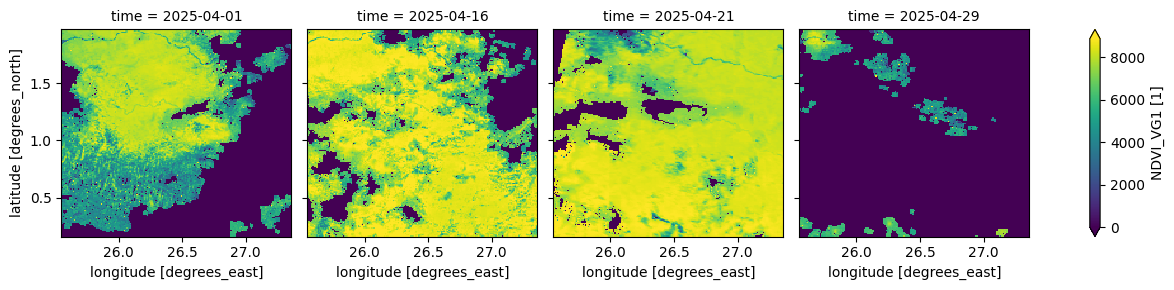

In [9]:
(ds_S3_syn_2_vg1['NDVI_VG1'].isel(time=[0, 15, 20, -2])).plot(robust=True, col="time", col_wrap=4);

**After applying the *scale factor*, pay close attention to the units.**

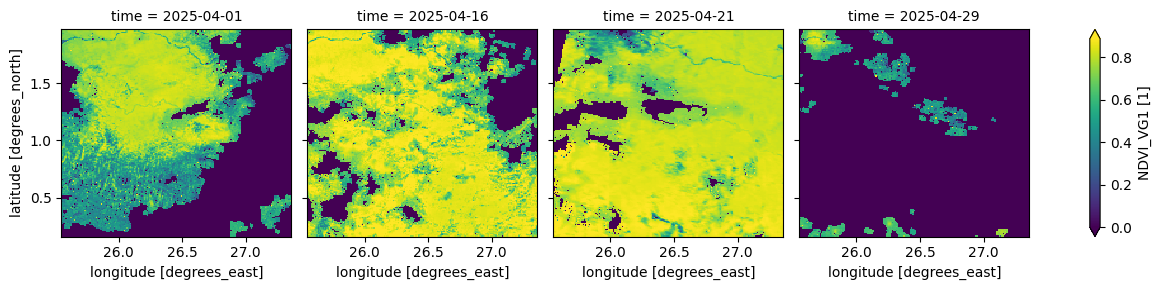

In [10]:
(ds_S3_syn_2_vg1['NDVI_VG1'].isel(time=[0, 15, 20, -2])*0.0001).plot(robust=True, col="time", col_wrap=4);

Before using any measurement band, always check whether a scale factor or offset needs to be applied before using the data for further analysis. After confirming this, the same process described above can be used to visualize all the other measurement bands available for the product.

---

## Additional information

<b> License </b> The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0).

Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

<b> Contact </b> If you need assistance, please post a question on the [DE Africa Slack channel](https://digitalearthafrica.slack.com/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).

If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

<b> Compatible datacube version </b>

In [11]:
print(datacube.__version__)

1.9.13


**Last Tested:**

In [12]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2026-07-02'